<a href="https://colab.research.google.com/github/einarhre/kaggle-projects/blob/main/Titanic/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

titanic_path = kagglehub.competition_download('titanic')

print('Data source import complete.')


# Titanic competition with TensorFlow Decision Forests

This notebook will take you through the steps needed to train a baseline Gradient Boosted Trees Model using TensorFlow Decision Forests and creating a submission on the Titanic competition.

This notebook shows:

1. How to do some basic pre-processing. For example, the passenger names will be tokenized, and ticket names will be splitted in parts.
1. How to train a Gradient Boosted Trees (GBT) with default parameters
1. How to train a GBT with improved default parameters
1. How to tune the parameters of a GBTs
1. How to train and ensemble many GBTs

# Imports dependencies

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import tensorflow as tf
import tensorflow_decision_forests as tfdf

print(f"Found TF-DF {tfdf.__version__}")

Found TF-DF 1.9.0


# Load dataset

In [3]:
train_df = pd.read_csv("data/train.csv")
serving_df = pd.read_csv("data/test.csv")

train_df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


# Prepare dataset

We will apply the following transformations on the dataset.

1. Tokenize the names. For example, "Braund, Mr. Owen Harris" will become ["Braund", "Mr.", "Owen", "Harris"].
2. Extract any prefix in the ticket. For example ticket "STON/O2. 3101282" will become "STON/O2." and 3101282.

In [3]:
def preprocess(df):
    df = df.copy()

    def normalize_name(x):
        return " ".join([v.strip(",()[].\"'") for v in x.split(" ")])

    def ticket_number(x):
        return x.split(" ")[-1]

    def ticket_item(x):
        items = x.split(" ")
        if len(items) == 1:
            return "NONE"
        return "_".join(items[0:-1])

    df["Name"] = df["Name"].apply(normalize_name)
    df["Ticket_number"] = df["Ticket"].apply(ticket_number)
    df["Ticket_item"] = df["Ticket"].apply(ticket_item)
    return df

preprocessed_train_df = preprocess(train_df)
preprocessed_serving_df = preprocess(serving_df)

preprocessed_train_df.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Ticket_number,Ticket_item
0,1,0,3,Braund Mr Owen Harris,male,22.0,1,0,A/5 21171,7.2500,NaN,S,21171,A/5
1,2,1,1,Cumings Mrs John Bradley Florence Briggs Thayer,female,38.0,1,0,PC 17599,71.2833,C85,C,17599,PC
2,3,1,3,Heikkinen Miss Laina,female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,3101282,STON/O2.
3,4,1,1,Futrelle Mrs Jacques Heath Lily May Peel,female,35.0,1,0,113803,53.1000,C123,S,113803,NONE
4,5,0,3,Allen Mr William Henry,male,35.0,0,0,373450,8.0500,NaN,S,373450,NONE


Let's keep the list of the input features of the model. Notably, we don't want to train our model on the "PassengerId" and "Ticket" features.

In [4]:
input_features = list(preprocessed_train_df.columns)
input_features.remove("Ticket")
input_features.remove("PassengerId")
input_features.remove("Survived")
#input_features.remove("Ticket_number")

print(f"Input features: {input_features}")

Input features: ['Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Cabin', 'Embarked', 'Ticket_number', 'Ticket_item']


# Convert Pandas dataset to TensorFlow Dataset

In [5]:
def tokenize_names(features, labels=None):
    """Divite the names into tokens. TF-DF can consume text tokens natively."""
    features["Name"] =  tf.strings.split(features["Name"])
    return features, labels

train_ds = tfdf.keras.pd_dataframe_to_tf_dataset(preprocessed_train_df,label="Survived").map(tokenize_names)
serving_ds = tfdf.keras.pd_dataframe_to_tf_dataset(preprocessed_serving_df).map(tokenize_names)

2025-06-25 11:36:08.738140: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2 Pro
2025-06-25 11:36:08.738482: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2025-06-25 11:36:08.738522: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.33 GB
2025-06-25 11:36:08.738905: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-06-25 11:36:08.739033: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


# Train model with default parameters

### Train model

First, we are training a GradientBoostedTreesModel model with the default parameters.

In [6]:
model = tfdf.keras.GradientBoostedTreesModel(
    verbose=0, # Very few logs
    features=[tfdf.keras.FeatureUsage(name=n) for n in input_features],
    exclude_non_specified_features=True, # Only use the features in "features"
    random_seed=1234,
)
model.fit(train_ds)

self_evaluation = model.make_inspector().evaluation()
print(f"Accuracy: {self_evaluation.accuracy} Loss:{self_evaluation.loss}")

[WARNING 25-06-25 11:36:12.1281 JST gradient_boosted_trees.cc:1840] "goss_alpha" set but "sampling_method" not equal to "GOSS".
[WARNING 25-06-25 11:36:12.1300 JST gradient_boosted_trees.cc:1851] "goss_beta" set but "sampling_method" not equal to "GOSS".
[WARNING 25-06-25 11:36:12.1300 JST gradient_boosted_trees.cc:1865] "selective_gradient_boosting_ratio" set but "sampling_method" not equal to "SELGB".
2025-06-25 11:36:13.727883: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.
[INFO 25-06-25 11:36:14.0550 JST kernel.cc:1233] Loading model from path /var/folders/1x/p6phdbd12z7bynhszry9zsww0000gn/T/tmpfef61x5f/model/ with prefix f363e23a3a684e9c
[INFO 25-06-25 11:36:14.0622 JST abstract_model.cc:1344] Engine "GradientBoostedTreesQuickScorerExtended" built
[INFO 25-06-25 11:36:14.0623 JST kernel.cc:1061] Use fast generic engine


Accuracy: 0.804347813129425 Loss:0.8922085165977478


# Train model with improved default parameters

Now you'll use some specific parameters when creating the GBT model

In [7]:
model = tfdf.keras.GradientBoostedTreesModel(
    verbose=0, # Very few logs
    features=[tfdf.keras.FeatureUsage(name=n) for n in input_features],
    exclude_non_specified_features=True, # Only use the features in "features"

    #num_trees=2000,

    # Only for GBT.
    # A bit slower, but great to understand the model.
    # compute_permutation_variable_importance=True,

    # Change the default hyper-parameters
    # hyperparameter_template="benchmark_rank1@v1",

    #num_trees=1000,
    #tuner=tuner

    min_examples=1,
    categorical_algorithm="RANDOM",
    #max_depth=4,
    shrinkage=0.05,
    #num_candidate_attributes_ratio=0.2,
    split_axis="SPARSE_OBLIQUE",
    sparse_oblique_normalization="MIN_MAX",
    sparse_oblique_num_projections_exponent=2.0,
    num_trees=2000,
    #validation_ratio=0.0,
    random_seed=1234,

)
model.fit(train_ds)

self_evaluation = model.make_inspector().evaluation()
print(f"Accuracy: {self_evaluation.accuracy} Loss:{self_evaluation.loss}")

[WARNING 25-06-25 11:36:20.7296 JST gradient_boosted_trees.cc:1840] "goss_alpha" set but "sampling_method" not equal to "GOSS".
[WARNING 25-06-25 11:36:20.7296 JST gradient_boosted_trees.cc:1851] "goss_beta" set but "sampling_method" not equal to "GOSS".
[WARNING 25-06-25 11:36:20.7296 JST gradient_boosted_trees.cc:1865] "selective_gradient_boosting_ratio" set but "sampling_method" not equal to "SELGB".


Accuracy: 0.77173912525177 Loss:1.0119096040725708


[INFO 25-06-25 11:36:21.2041 JST kernel.cc:1233] Loading model from path /var/folders/1x/p6phdbd12z7bynhszry9zsww0000gn/T/tmp94ky6fk0/model/ with prefix 40ebeb5269244295
[INFO 25-06-25 11:36:21.2081 JST decision_forest.cc:734] Model loaded with 54 root(s), 2824 node(s), and 10 input feature(s).
[INFO 25-06-25 11:36:21.2081 JST kernel.cc:1061] Use fast generic engine


Let's look at the model and you can also notice the information about variable importance that the model figured out

In [8]:
model.summary()

Model: "gradient_boosted_trees_model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
Total params: 1 (1.00 Byte)
Trainable params: 0 (0.00 Byte)
Non-trainable params: 1 (1.00 Byte)
_________________________________________________________________
Type: "GRADIENT_BOOSTED_TREES"
Task: CLASSIFICATION
Label: "__LABEL"

Input Features (11):
	Age
	Cabin
	Embarked
	Fare
	Name
	Parch
	Pclass
	Sex
	SibSp
	Ticket_item
	Ticket_number

No weights

Variable Importance: INV_MEAN_MIN_DEPTH:
    1.           "Sex"  0.431313 ################
    2.           "Age"  0.373986 ############
    3.          "Fare"  0.250863 ####
    4.          "Name"  0.225272 ###
    5.   "Ticket_item"  0.182111 
    6.      "Embarked"  0.181387 
    7. "Ticket_number"  0.180897 
    8.        "Pclass"  0.178279 
    9.         "Parch"  0.175249 
   10.         "SibSp"  0.172167 

Variable Importance: NUM_AS_ROOT:
    1.  "Sex" 39.00000

# Make predictions

In [10]:
def prediction_to_kaggle_format(model, threshold=0.5):
    proba_survive = model.predict(serving_ds, verbose=0)[:,0]
    return pd.DataFrame({
        "PassengerId": serving_df["PassengerId"],
        "Survived": (proba_survive >= threshold).astype(int)
    })

def make_submission(kaggle_predictions):
    path="working/submission.csv"
    kaggle_predictions.to_csv(path, index=False)
    print(f"Submission exported to {path}")

kaggle_predictions = prediction_to_kaggle_format(model)
make_submission(kaggle_predictions)
!head /kaggle/working/submission.csv

Submission exported to working/submission.csv
head: /kaggle/working/submission.csv: No such file or directory


# Training a model with hyperparameter tunning

Hyper-parameter tuning is enabled by specifying the tuner constructor argument of the model. The tuner object contains all the configuration of the tuner (search space, optimizer, trial and objective).


In [11]:
tuner = tfdf.tuner.RandomSearch(num_trials=1000)
tuner.choice("min_examples", [2, 5, 7, 10])
tuner.choice("categorical_algorithm", ["CART", "RANDOM"])

local_search_space = tuner.choice("growing_strategy", ["LOCAL"])
local_search_space.choice("max_depth", [3, 4, 5, 6, 8])

global_search_space = tuner.choice("growing_strategy", ["BEST_FIRST_GLOBAL"], merge=True)
global_search_space.choice("max_num_nodes", [16, 32, 64, 128, 256])

#tuner.choice("use_hessian_gain", [True, False])
tuner.choice("shrinkage", [0.02, 0.05, 0.10, 0.15])
tuner.choice("num_candidate_attributes_ratio", [0.2, 0.5, 0.9, 1.0])


tuner.choice("split_axis", ["AXIS_ALIGNED"])
oblique_space = tuner.choice("split_axis", ["SPARSE_OBLIQUE"], merge=True)
oblique_space.choice("sparse_oblique_normalization",
                     ["NONE", "STANDARD_DEVIATION", "MIN_MAX"])
oblique_space.choice("sparse_oblique_weights", ["BINARY", "CONTINUOUS"])
oblique_space.choice("sparse_oblique_num_projections_exponent", [1.0, 1.5])

# Tune the model. Notice the `tuner=tuner`.
tuned_model = tfdf.keras.GradientBoostedTreesModel(tuner=tuner)
tuned_model.fit(train_ds, verbose=0)

tuned_self_evaluation = tuned_model.make_inspector().evaluation()
print(f"Accuracy: {tuned_self_evaluation.accuracy} Loss:{tuned_self_evaluation.loss}")

Use /var/folders/1x/p6phdbd12z7bynhszry9zsww0000gn/T/tmpmmb908tc as temporary training directory


[WARNING 25-06-25 11:37:17.7622 JST gradient_boosted_trees.cc:1840] "goss_alpha" set but "sampling_method" not equal to "GOSS".
[WARNING 25-06-25 11:37:17.7623 JST gradient_boosted_trees.cc:1851] "goss_beta" set but "sampling_method" not equal to "GOSS".
[WARNING 25-06-25 11:37:17.7623 JST gradient_boosted_trees.cc:1865] "selective_gradient_boosting_ratio" set but "sampling_method" not equal to "SELGB".


[INFO 25-06-25 11:39:52.2235 JST kernel.cc:1233] Loading model from path /var/folders/1x/p6phdbd12z7bynhszry9zsww0000gn/T/tmpmmb908tc/model/ with prefix c9119f5d474b4bd4
[INFO 25-06-25 11:39:52.2287 JST decision_forest.cc:734] Model loaded with 25 root(s), 775 node(s), and 12 input feature(s).
[INFO 25-06-25 11:39:52.2287 JST abstract_model.cc:1344] Engine "GradientBoostedTreesGeneric" built
[INFO 25-06-25 11:39:52.2287 JST kernel.cc:1061] Use fast generic engine


Accuracy: 0.8767123222351074 Loss:0.6808041334152222


In the last line in the cell above, you can see the accuracy is higher than previously with default parameters and parameters set by hand.

This is the main idea behing hyperparameter tuning.

For more information you can follow this tutorial: [Automated hyper-parameter tuning](https://www.tensorflow.org/decision_forests/tutorials/automatic_tuning_colab)

# Making an ensemble

Here you'll create 100 models with different seeds and combine their results

This approach removes a little bit the random aspects related to creating ML models

In the GBT creation is used the `honest` parameter. It will use different training examples to infer the structure and the leaf values. This regularization technique trades examples for bias estimates.

In [12]:
predictions = None
num_predictions = 0

for i in range(100):
    print(f"i:{i}")
    # Possible models: GradientBoostedTreesModel or RandomForestModel
    model = tfdf.keras.GradientBoostedTreesModel(
        verbose=0, # Very few logs
        features=[tfdf.keras.FeatureUsage(name=n) for n in input_features],
        exclude_non_specified_features=True, # Only use the features in "features"

        #min_examples=1,
        #categorical_algorithm="RANDOM",
        ##max_depth=4,
        #shrinkage=0.05,
        ##num_candidate_attributes_ratio=0.2,
        #split_axis="SPARSE_OBLIQUE",
        #sparse_oblique_normalization="MIN_MAX",
        #sparse_oblique_num_projections_exponent=2.0,
        #num_trees=2000,
        ##validation_ratio=0.0,
        random_seed=i,
        honest=True,
    )
    model.fit(train_ds)

    sub_predictions = model.predict(serving_ds, verbose=0)[:,0]
    if predictions is None:
        predictions = sub_predictions
    else:
        predictions += sub_predictions
    num_predictions += 1

predictions/=num_predictions

kaggle_predictions = pd.DataFrame({
        "PassengerId": serving_df["PassengerId"],
        "Survived": (predictions >= 0.5).astype(int)
    })

make_submission(kaggle_predictions)

i:0


[WARNING 25-06-25 11:40:12.5879 JST gradient_boosted_trees.cc:1840] "goss_alpha" set but "sampling_method" not equal to "GOSS".
[WARNING 25-06-25 11:40:12.5879 JST gradient_boosted_trees.cc:1851] "goss_beta" set but "sampling_method" not equal to "GOSS".
[WARNING 25-06-25 11:40:12.5879 JST gradient_boosted_trees.cc:1865] "selective_gradient_boosting_ratio" set but "sampling_method" not equal to "SELGB".


[INFO 25-06-25 11:40:12.8809 JST kernel.cc:1233] Loading model from path /var/folders/1x/p6phdbd12z7bynhszry9zsww0000gn/T/tmpe9la_5qg/model/ with prefix c63ccccdf251476a
[INFO 25-06-25 11:40:12.8826 JST abstract_model.cc:1344] Engine "GradientBoostedTreesQuickScorerExtended" built
[INFO 25-06-25 11:40:12.8826 JST kernel.cc:1061] Use fast generic engine


i:1


[WARNING 25-06-25 11:40:13.1115 JST gradient_boosted_trees.cc:1840] "goss_alpha" set but "sampling_method" not equal to "GOSS".
[WARNING 25-06-25 11:40:13.1115 JST gradient_boosted_trees.cc:1851] "goss_beta" set but "sampling_method" not equal to "GOSS".
[WARNING 25-06-25 11:40:13.1115 JST gradient_boosted_trees.cc:1865] "selective_gradient_boosting_ratio" set but "sampling_method" not equal to "SELGB".


...

i:98


[WARNING 25-06-25 11:41:10.5151 JST gradient_boosted_trees.cc:1840] "goss_alpha" set but "sampling_method" not equal to "GOSS".
[WARNING 25-06-25 11:41:10.5151 JST gradient_boosted_trees.cc:1851] "goss_beta" set but "sampling_method" not equal to "GOSS".
[WARNING 25-06-25 11:41:10.5151 JST gradient_boosted_trees.cc:1865] "selective_gradient_boosting_ratio" set but "sampling_method" not equal to "SELGB".
[INFO 25-06-25 11:41:11.0353 JST kernel.cc:1233] Loading model from path /var/folders/1x/p6phdbd12z7bynhszry9zsww0000gn/T/tmpsbrpr_r7/model/ with prefix 5973ed761fc54726
[INFO 25-06-25 11:41:11.0431 JST kernel.cc:1061] Use fast generic engine


i:99


[WARNING 25-06-25 11:41:11.2820 JST gradient_boosted_trees.cc:1840] "goss_alpha" set but "sampling_method" not equal to "GOSS".
[WARNING 25-06-25 11:41:11.2820 JST gradient_boosted_trees.cc:1851] "goss_beta" set but "sampling_method" not equal to "GOSS".
[WARNING 25-06-25 11:41:11.2820 JST gradient_boosted_trees.cc:1865] "selective_gradient_boosting_ratio" set but "sampling_method" not equal to "SELGB".
[INFO 25-06-25 11:41:11.9012 JST kernel.cc:1233] Loading model from path /var/folders/1x/p6phdbd12z7bynhszry9zsww0000gn/T/tmpypke5mtd/model/ with prefix 90393745c05d4a30
[INFO 25-06-25 11:41:11.9113 JST kernel.cc:1061] Use fast generic engine


Submission exported to working/submission.csv


# What is next

If you want to learn more about TensorFlow Decision Forests and its advanced features, you can follow the official documentation [here](https://www.tensorflow.org/decision_forests)

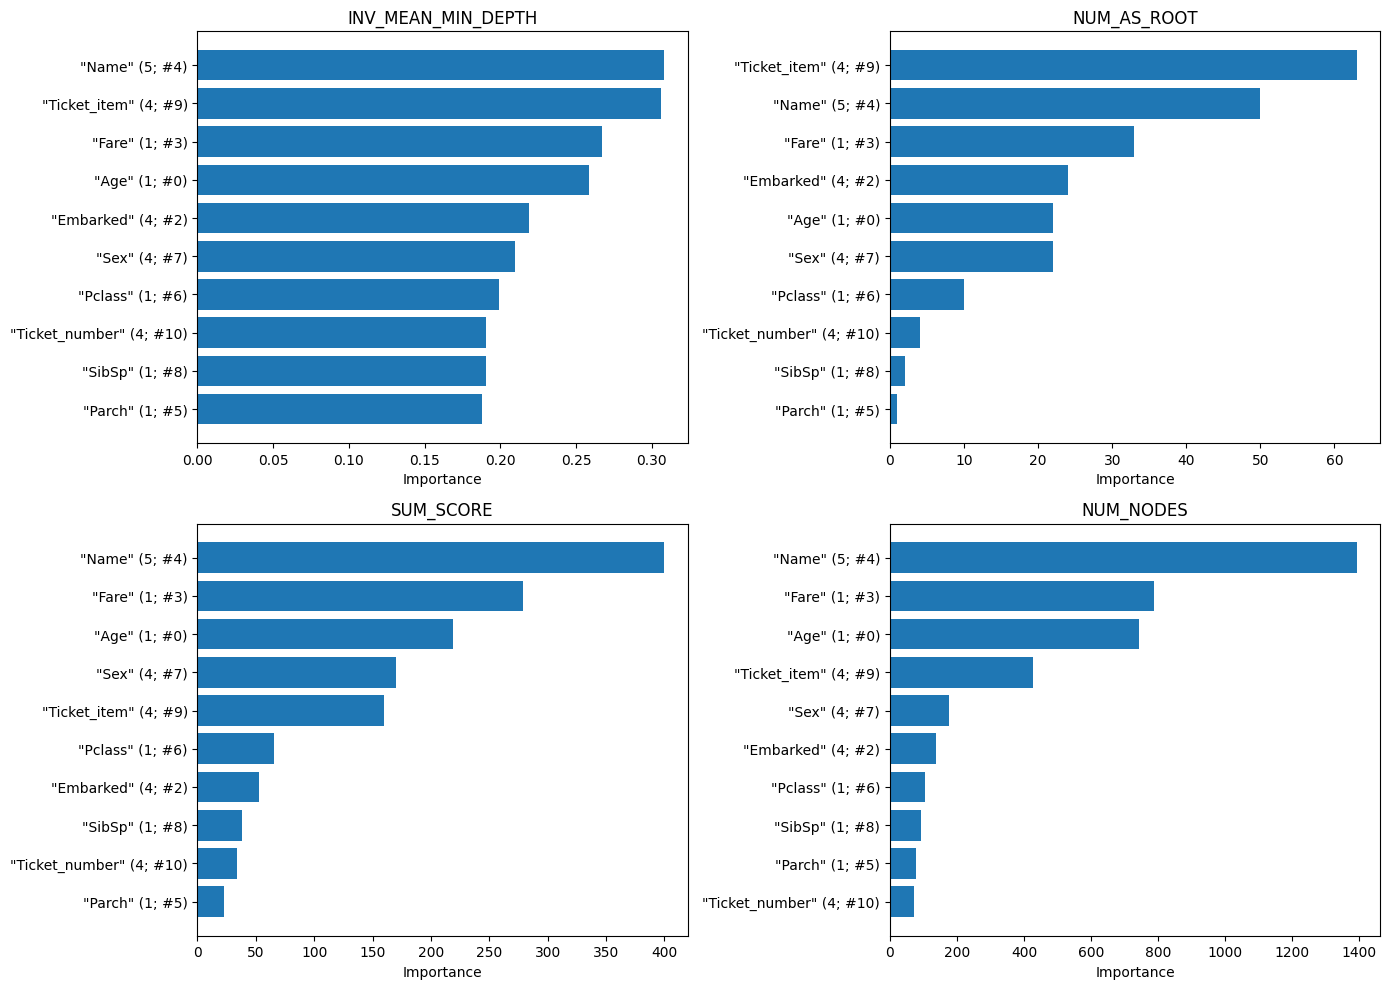

In [ ]:
import matplotlib.pyplot as plt

inspector = model.make_inspector()

importance_keys = inspector.variable_importances().keys()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

variable_importances = inspector.variable_importances()

for i, key in enumerate(importance_keys):
    if key in variable_importances:
        raw_importances = variable_importances[key]

        try:
            features = [str(item['feature']) for item in raw_importances]
            scores = [item['importance'] for item in raw_importances]
        except (TypeError, KeyError):
            features = [str(item[0]) for item in raw_importances]
            scores = [item[1] for item in raw_importances]

        features, scores = zip(*sorted(zip(features, scores), key=lambda x: x[1], reverse=True))

        axes[i].barh(features, scores)
        axes[i].set_title(f"{key}")
        axes[i].invert_yaxis()
        axes[i].set_xlabel("Importance")
    else:
        axes[i].set_visible(False)

plt.tight_layout()
plt.show()

# Other models

In [30]:
from sklearn.calibration import LabelEncoder
from sklearn.cluster import KMeans

train = train_df.copy()
test = serving_df.copy()

def comprehensive_feature_engineering(df):
    """Comprehensive feature engineering with maximum possible features"""
    df = df.copy()    
    
    # ==================== 1. Basic missing value handling ====================
    df['Fare'].fillna(df['Fare'].median(), inplace=True)
    df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)
    
    # ==================== 2. Advanced Title analysis ====================
    df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
    
    # Detailed title classification based on survival rates
    title_survival_mapping = {
        # High survival rate group
        'Miss': 'Young_Female',      # Young women
        'Mrs': 'Married_Female',     # Married women
        'Master': 'Young_Male',      # Boys
        'Mlle': 'Young_Female',
        'Ms': 'Young_Female',
        'Mme': 'Married_Female',
        
        # Medium survival rate group
        'Dr': 'Professional',        # Professionals
        'Rev': 'Religious',          # Religious
        'Col': 'Military',           # Military
        'Major': 'Military',
        'Capt': 'Military',
        
        # Low survival rate group  
        'Mr': 'Adult_Male',          # Adult males
        
        # Ultra high survival rate group
        'Countess': 'Nobility',      # Nobility
        'Lady': 'Nobility',
        'Sir': 'Nobility',
        'Don': 'Nobility',
        'Dona': 'Nobility',
        'Jonkheer': 'Nobility'
    }
    df['Title'] = df['Title'].map(title_survival_mapping)
    df['Title'].fillna('Other', inplace=True)
    
    # Numeric encoding of titles (by survival rate order)
    title_order = {'Nobility': 5, 'Young_Female': 4, 'Married_Female': 4, 'Young_Male': 3, 
                   'Professional': 2, 'Religious': 2, 'Military': 2, 'Adult_Male': 1, 'Other': 1}
    df['Title_Numeric'] = df['Title'].map(title_order)    
    
    # ==================== 3. Advanced age processing ====================
    # Precise age imputation by Title, Pclass, Sex
    age_medians = df.groupby(['Title', 'Pclass', 'Sex'])['Age'].median()
    for (title, pclass, sex), median_age in age_medians.items():
        mask = (df['Title'] == title) & (df['Pclass'] == pclass) & (df['Sex'] == sex) & df['Age'].isnull()
        df.loc[mask, 'Age'] = median_age
    
    # Fill remaining missing values by Title
    title_age_medians = df.groupby('Title')['Age'].median()
    for title, median_age in title_age_medians.items():
        mask = (df['Title'] == title) & df['Age'].isnull()
        df.loc[mask, 'Age'] = median_age
    
    # Advanced age transformations
    df['Age_Squared'] = df['Age'] ** 2
    df['Age_Cubed'] = df['Age'] ** 3
    df['Age_Sqrt'] = np.sqrt(df['Age'])
    df['Age_Log'] = np.log1p(df['Age'])
    
    # Detailed age groups
    df['AgeGroup_Detailed'] = 'Adult'
    df.loc[df['Age'] <= 5, 'AgeGroup_Detailed'] = 'Baby'
    df.loc[(df['Age'] > 5) & (df['Age'] <= 12), 'AgeGroup_Detailed'] = 'Child'
    df.loc[(df['Age'] > 12) & (df['Age'] <= 18), 'AgeGroup_Detailed'] = 'Teen'
    df.loc[(df['Age'] > 18) & (df['Age'] <= 25), 'AgeGroup_Detailed'] = 'YoungAdult'
    df.loc[(df['Age'] > 25) & (df['Age'] <= 35), 'AgeGroup_Detailed'] = 'Adult'
    df.loc[(df['Age'] > 35) & (df['Age'] <= 50), 'AgeGroup_Detailed'] = 'MiddleAge'
    df.loc[(df['Age'] > 50) & (df['Age'] <= 65), 'AgeGroup_Detailed'] = 'Senior'
    df.loc[df['Age'] > 65, 'AgeGroup_Detailed'] = 'Elderly'
    
    # Statistical age features
    df['Age_Bin'] = pd.cut(df['Age'], bins=10, labels=False)
    df['Age_Quintile'] = pd.qcut(df['Age'], q=5, labels=False)    
    
    # ==================== 4. Detailed family analysis ====================
    df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
    df['IsAlone'] = (df['FamilySize'] == 1).astype(int)
    df['HasSiblings'] = (df['SibSp'] > 0).astype(int)
    df['HasParentsChildren'] = (df['Parch'] > 0).astype(int)
    df['HasBoth_SibSp_Parch'] = ((df['SibSp'] > 0) & (df['Parch'] > 0)).astype(int)
    
    # Optimal family composition for survival
    df['OptimalFamilySize'] = ((df['FamilySize'] >= 2) & (df['FamilySize'] <= 4)).astype(int)
    df['LargeFamilyPenalty'] = (df['FamilySize'] >= 7).astype(int)
    
    # Family role based on age
    df['FamilyRole'] = 'Unknown'
    df.loc[(df['Age'] < 18) & (df['Parch'] > 0), 'FamilyRole'] = 'Child'
    df.loc[(df['Age'] >= 18) & (df['Parch'] > 0) & (df['SibSp'] == 0), 'FamilyRole'] = 'Parent'
    df.loc[(df['Age'] >= 18) & (df['SibSp'] > 0) & (df['Parch'] == 0), 'FamilyRole'] = 'Sibling'
    df.loc[df['IsAlone'] == 1, 'FamilyRole'] = 'Alone'    
    
    # ==================== 5. Detailed ticket analysis ====================
    # Ticket sharing information
    df['TicketCount'] = df.groupby('Ticket')['Ticket'].transform('count')
    df['SharedTicket'] = (df['TicketCount'] > 1).astype(int)
    df['TicketSharingRatio'] = df['TicketCount'] / df['FamilySize']
    
    # Extract numeric part from ticket
    df['TicketNumber'] = df['Ticket'].str.extract('(\d+)', expand=False).astype(float)
    df['TicketNumber'].fillna(0, inplace=True)
    df['HasTicketNumber'] = (df['TicketNumber'] > 0).astype(int)
    
    # Detailed ticket prefix analysis
    df['TicketPrefix'] = df['Ticket'].str.extract('([A-Za-z/\.]+)', expand=False)
    df['TicketPrefix'].fillna('NONE', inplace=True)
    df['TicketPrefix'] = df['TicketPrefix'].str.upper()
    
    # Special ticket patterns
    df['TicketHasSlash'] = df['Ticket'].str.contains('/').astype(int)
    df['TicketHasDot'] = df['Ticket'].str.contains('\.').astype(int)
    df['TicketLength'] = df['Ticket'].str.len()
    
    # ==================== 6. Detailed fare analysis ====================
    # Fare per person (divided by ticket count for shared tickets)
    df['FarePerPerson'] = df['Fare'] / df['TicketCount']
    df['FarePerFamily'] = df['Fare'] / df['FamilySize']
    
    # Statistical fare transformations
    df['Fare_Log'] = np.log1p(df['Fare'])
    df['Fare_Sqrt'] = np.sqrt(df['Fare'])
    df['FarePerPerson_Log'] = np.log1p(df['FarePerPerson'])
    
    # Relative fare position within each class
    for pclass in [1, 2, 3]:
        class_fares = df[df['Pclass'] == pclass]['Fare']
        df[f'Fare_Pclass{pclass}_Rank'] = 0
        mask = df['Pclass'] == pclass
        df.loc[mask, f'Fare_Pclass{pclass}_Rank'] = df.loc[mask, 'Fare'].rank(pct=True)
    
    # Fare outlier detection
    Q1, Q3 = df['Fare'].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    df['FareOutlier'] = ((df['Fare'] < (Q1 - 1.5 * IQR)) | (df['Fare'] > (Q3 + 1.5 * IQR))).astype(int)
    df['FareVeryHigh'] = (df['Fare'] > df['Fare'].quantile(0.95)).astype(int)
    df['FareVeryLow'] = (df['Fare'] < df['Fare'].quantile(0.05)).astype(int)
    
    # Fare binning
    df['FareGroup'] = pd.qcut(df['Fare'], q=10, labels=False, duplicates='drop')
    df['FareGroup_Coarse'] = pd.qcut(df['Fare'], q=4, labels=False, duplicates='drop')    
    
    # ==================== 7. Comprehensive cabin analysis ====================
    df['HasCabin'] = (~df['Cabin'].isnull()).astype(int)
    
    # Deck information
    df['Deck'] = df['Cabin'].str[0]
    df['Deck'].fillna('Unknown', inplace=True)
    
    # Deck safety ranking (by survival rate)
    deck_safety = {'A': 6, 'B': 5, 'C': 4, 'D': 3, 'E': 2, 'F': 1, 'G': 1, 'T': 1, 'Unknown': 0}
    df['DeckSafety'] = df['Deck'].map(deck_safety)
    
    # Detailed cabin number analysis
    df['CabinNumber'] = df['Cabin'].str.extract('(\d+)', expand=False).astype(float)
    df['CabinNumber'].fillna(0, inplace=True)
    df['HasCabinNumber'] = (df['CabinNumber'] > 0).astype(int)
    
    # Multiple cabin analysis
    df['CabinCount'] = df['Cabin'].str.count(' ').fillna(0) + df['HasCabin']
    df['MultipleCabins'] = (df['CabinCount'] > 1).astype(int)
    
    # Estimated cabin position (front/middle/rear)
    df['CabinPosition'] = 'Unknown'
    df.loc[(df['CabinNumber'] > 0) & (df['CabinNumber'] <= 50), 'CabinPosition'] = 'Front'
    df.loc[(df['CabinNumber'] > 50) & (df['CabinNumber'] <= 100), 'CabinPosition'] = 'Middle'
    df.loc[df['CabinNumber'] > 100, 'CabinPosition'] = 'Rear'
    
    # ==================== 8. Detailed name analysis ====================
    df['NameLength'] = df['Name'].str.len()
    df['NameWordCount'] = df['Name'].str.split().str.len()
    
    # Parentheses information (maiden names, etc.)
    df['HasNameParentheses'] = df['Name'].str.contains('\(').astype(int)
    df['NameInParentheses'] = df['Name'].str.extract('\(([^)]+)\)', expand=False)
    df['HasMaidenName'] = df['NameInParentheses'].str.contains('nee|née', case=False, na=False).astype(int)
    
    # Last name analysis
    df['LastName'] = df['Name'].str.split(',').str[0]
    df['LastNameLength'] = df['LastName'].str.len()
    
    # Name complexity (indicator of social status)
    df['NameComplexity'] = (df['NameWordCount'] + df['HasNameParentheses'] + 
                           (df['NameLength'] / 20).astype(int))    
    
    # ==================== 9. Detailed embarkation analysis ====================
    # Embarkation port characteristics (survival rate, social background)
    embarked_features = {
        'C': {'survival_rate': 0.55, 'wealth_level': 3, 'distance': 1},  # Cherbourg (France)
        'Q': {'survival_rate': 0.39, 'wealth_level': 1, 'distance': 2},  # Queenstown (Ireland)
        'S': {'survival_rate': 0.34, 'wealth_level': 2, 'distance': 3}   # Southampton (UK)
    }
    
    for port, features in embarked_features.items():
        df[f'Embarked_{port}'] = (df['Embarked'] == port).astype(int)
    
    df['EmbarkedWealthLevel'] = df['Embarked'].map({port: features['wealth_level'] 
                                                   for port, features in embarked_features.items()})    
    
    # ==================== 10. Interaction features ====================
    # Basic interactions
    df['Sex_Pclass'] = df['Sex'].astype(str) + '_' + df['Pclass'].astype(str)
    df['Age_Sex'] = df['Age'].astype(str) + '_' + df['Sex'].astype(str)
    df['Title_Pclass'] = df['Title'].astype(str) + '_' + df['Pclass'].astype(str)
    df['Embarked_Pclass'] = df['Embarked'].astype(str) + '_' + df['Pclass'].astype(str)
    
    # Numeric interactions
    df['Age_Pclass_Numeric'] = df['Age'] * df['Pclass']
    df['Age_Fare'] = df['Age'] * df['Fare']
    df['FamilySize_Pclass'] = df['FamilySize'] * df['Pclass']
    df['FarePerPerson_Pclass'] = df['FarePerPerson'] * df['Pclass']
    
    # Complex interactions
    df['Wealth_Indicator'] = (df['Pclass'] == 1).astype(int) + df['HasCabin'] + (df['Fare'] > df['Fare'].quantile(0.8)).astype(int)
    df['Survival_Priority'] = (df['Sex'] == 'female').astype(int) + (df['Age'] < 18).astype(int) + (df['Pclass'] == 1).astype(int)    
    
    # ==================== 11. Advanced statistical features ====================
    # Group statistics
    group_stats = ['Age', 'Fare', 'FamilySize']
    group_by_cols = ['Pclass', 'Sex', 'Embarked', 'Title']
    
    for group_col in group_by_cols:
        for stat_col in group_stats:
            # Difference from group mean
            group_mean = df.groupby(group_col)[stat_col].transform('mean')
            df[f'{stat_col}_{group_col}_MeanDiff'] = df[stat_col] - group_mean
            
            # Standardization within group
            group_std = df.groupby(group_col)[stat_col].transform('std')
            df[f'{stat_col}_{group_col}_Normalized'] = (df[stat_col] - group_mean) / (group_std + 1e-8)
    
    # Ranking features
    df['Age_Rank'] = df['Age'].rank(pct=True)
    df['Fare_Rank'] = df['Fare'].rank(pct=True)
    df['FamilySize_Rank'] = df['FamilySize'].rank(pct=True)    
    
    # ==================== 12. Clustering features ====================
    # Clustering on numeric features
    cluster_features = ['Age', 'Fare', 'FamilySize', 'NameLength']
    cluster_data = df[cluster_features].fillna(df[cluster_features].median())
    
    # K-means clustering
    kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
    df['Cluster_Passenger'] = kmeans.fit_predict(cluster_data)
    
    # Relative position within cluster
    for i in range(5):
        cluster_mask = df['Cluster_Passenger'] == i
        if cluster_mask.sum() > 0:
            df.loc[cluster_mask, 'Age_ClusterRank'] = df.loc[cluster_mask, 'Age'].rank(pct=True)
            df.loc[cluster_mask, 'Fare_ClusterRank'] = df.loc[cluster_mask, 'Fare'].rank(pct=True)    
    
    # ==================== 13. Special pattern detection ====================
    # VIP passenger detection
    df['IsVIP'] = ((df['Pclass'] == 1) & (df['Fare'] > df['Fare'].quantile(0.9)) & 
                   (df['HasCabin'] == 1)).astype(int)
    
    # High-risk combinations
    df['HighRisk'] = ((df['Sex'] == 'male') & (df['Age'] > 18) & (df['Pclass'] == 3)).astype(int)
    
    # Women and children first policy
    df['WomenAndChildren'] = ((df['Sex'] == 'female') | (df['Age'] < 18)).astype(int)
    
    # Possible crew members (zero or extremely low fare)
    df['PossibleCrew'] = ((df['Fare'] == 0) | (df['Fare'] < 5)).astype(int)
    
    # Family separation degree
    df['FamilySeparation'] = np.abs(df['FamilySize'] - df['TicketCount'])    
    
    # ==================== 14. Pseudo time-series features ====================
    # Assume PassengerId as boarding order
    df['BoardingOrder'] = df.index  # Proxy for boarding sequence
    df['BoardingOrder_Normalized'] = df['BoardingOrder'] / len(df)
    
    # Boarding order features
    df['EarlyBoarder'] = (df['BoardingOrder_Normalized'] < 0.33).astype(int)
    df['LateBoarder'] = (df['BoardingOrder_Normalized'] > 0.67).astype(int)    
    
    # ==================== 15. Outlier and anomaly detection ====================
    # Multi-angle anomaly detection
    numeric_cols = ['Age', 'Fare', 'FamilySize', 'NameLength']
    
    for col in numeric_cols:
        Q1, Q3 = df[col].quantile([0.25, 0.75])
        IQR = Q3 - Q1
        df[f'{col}_Outlier'] = ((df[col] < (Q1 - 1.5 * IQR)) | 
                               (df[col] > (Q3 + 1.5 * IQR))).astype(int)
    
    # Total anomaly score
    outlier_cols = [col for col in df.columns if col.endswith('_Outlier')]
    df['TotalOutlierScore'] = df[outlier_cols].sum(axis=1)
    
    return df

def encode_features(train_df, test_df):
    """Encode categorical variables"""
    combined = pd.concat([train_df, test_df], ignore_index=True)
    
    # Identify categorical features
    categorical_features = []
    for col in combined.columns:
        if combined[col].dtype == 'object':
            categorical_features.append(col)    
    
    # Label encoding
    for feature in categorical_features:
        le = LabelEncoder()
        combined[feature] = le.fit_transform(combined[feature].astype(str))
    
    # Split back
    train_encoded = combined[:len(train_df)].copy()
    test_encoded = combined[len(train_df):].copy()
    
    return train_encoded, test_encoded

def select_features(df):
    """Feature selection (select high-importance features)"""
    # Exclude unnecessary features
    exclude_features = ['PassengerId', 'Name', 'Ticket', 'Cabin', 'Survived']
    
    features = [col for col in df.columns if col not in exclude_features]    
    
    return df[features]

train_fe = comprehensive_feature_engineering(train)
test_fe = comprehensive_feature_engineering(test)

train_encoded, test_encoded = encode_features(train_fe, test_fe)

train_final = select_features(train_encoded)
test_final = select_features(test_encoded)

/var/folders/1x/p6phdbd12z7bynhszry9zsww0000gn/T/ipykernel_47099/3271828325.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Fare'].fillna(df['Fare'].median(), inplace=True)
/var/folders/1x/p6phdbd12z7bynhszry9zsww0000gn/T/ipykernel_47099/3271828325.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting value

In [31]:
from sklearn.model_selection import train_test_split

X_train = select_features(train_encoded)
X_test = select_features(test_encoded)
y = train_df['Survived']
X_train, X_val, y_train, y_val = train_test_split(X_train, y, test_size=0.3, random_state=1)

In [32]:
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier

xgb_estimator = XGBClassifier(random_state=1)
xgb_estimator.fit(X_train, y_train)
xgb_estimator_model_train_perf = accuracy_score(
    y_val, xgb_estimator.predict(X_val)
)
xgb_estimator_model_train_perf

0.8022388059701493

<Axes: xlabel='Importance', ylabel='None'>

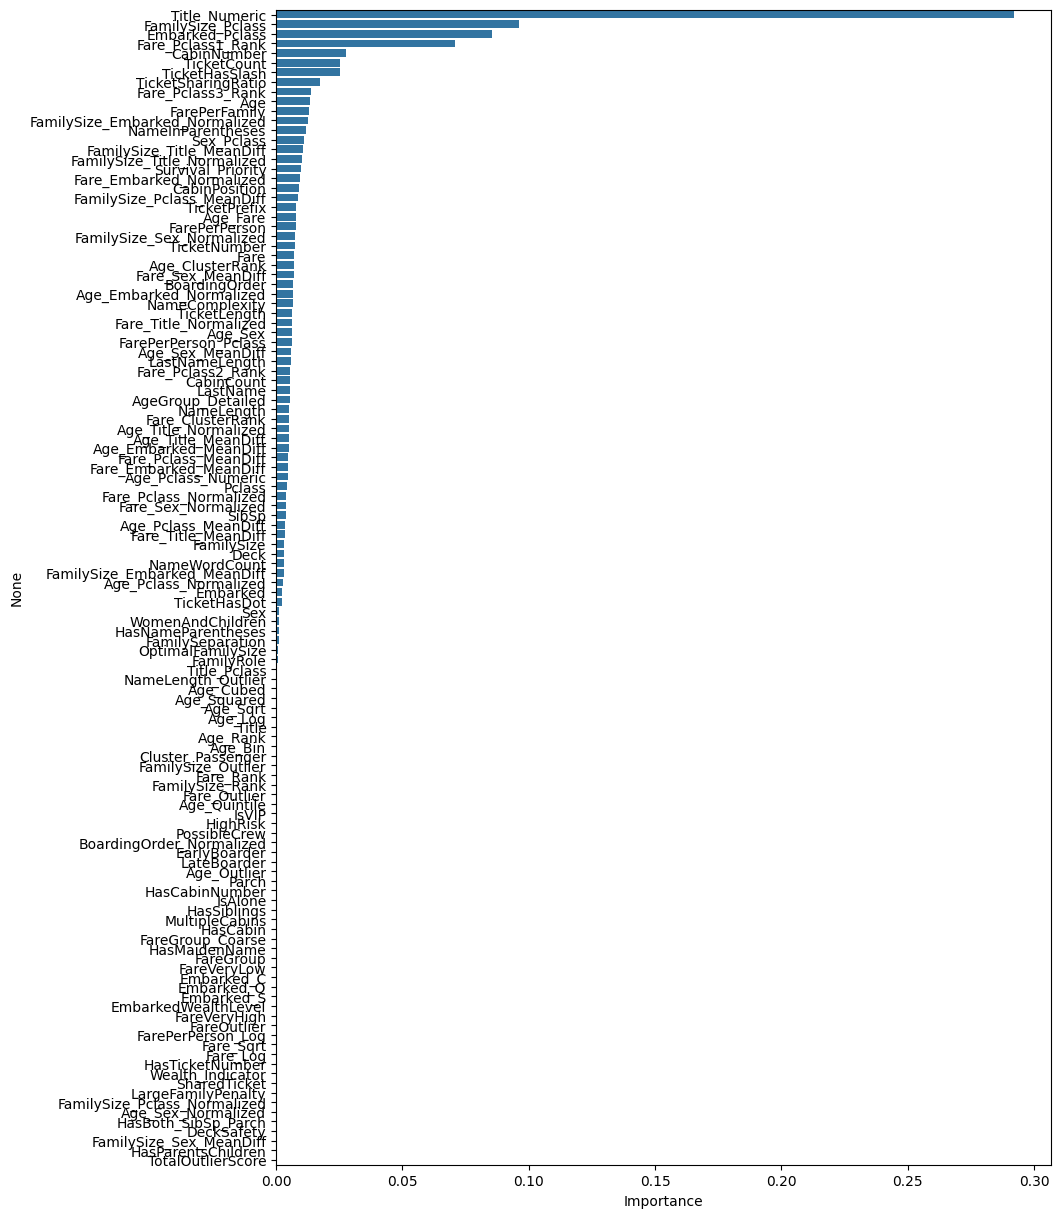

In [33]:
# Plot the feature importance
f, ax = plt.subplots(1,1,figsize=(10,15))
columns = X_train.columns

importances = xgb_estimator.feature_importances_

importance_df = pd.DataFrame(importances, index = columns, columns = ['Importance']).sort_values(by = 'Importance', ascending = False)

sns.barplot(x=importance_df.Importance,y=importance_df.index,ax=ax)

In [34]:
top_features = importance_df[importance_df.Importance > 0.01].index.tolist()
top_features

['Title_Numeric',
 'FamilySize_Pclass',
 'Embarked_Pclass',
 'Fare_Pclass1_Rank',
 'CabinNumber',
 'TicketCount',
 'TicketHasSlash',
 'TicketSharingRatio',
 'Fare_Pclass3_Rank',
 'Age',
 'FarePerFamily',
 'FamilySize_Embarked_Normalized',
 'NameInParentheses',
 'Sex_Pclass',
 'FamilySize_Title_MeanDiff',
 'FamilySize_Title_Normalized']

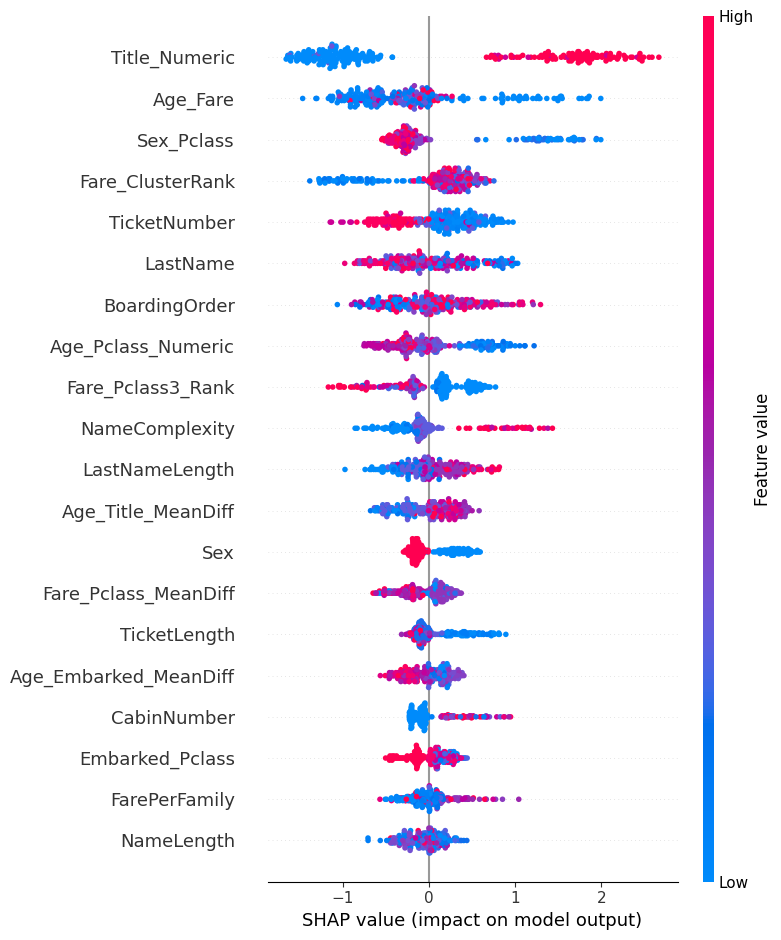

In [35]:
import shap

explainer = shap.Explainer(xgb_estimator, X_train)
shap_values = explainer(X_val)

plt.figure(figsize=(5, 10))
shap.summary_plot(shap_values, X_val)

# Ensenble

In [48]:
# Advanced ensemble model
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.discriminant_analysis import StandardScaler
from sklearn.ensemble import ExtraTreesClassifier, GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC


class UltimateEnsemble(BaseEstimator, ClassifierMixin):
    def __init__(self, random_state=42):
        self.random_state = random_state
        self.models = {
            'rf': RandomForestClassifier(n_estimators=300, max_depth=8, 
                                       min_samples_split=5, min_samples_leaf=2, 
                                       random_state=self.random_state),
            'et': ExtraTreesClassifier(n_estimators=300, max_depth=8,
                                     min_samples_split=5, min_samples_leaf=2,
                                     random_state=self.random_state),
            'gb': GradientBoostingClassifier(n_estimators=300, max_depth=6, 
                                           learning_rate=0.05, subsample=0.8,
                                           random_state=self.random_state),
            'xgb': XGBClassifier(n_estimators=300, max_depth=6,
                                learning_rate=0.05, subsample=0.8,
                                random_state=self.random_state, use_label_encoder=False, eval_metric='logloss'),
            'lr': LogisticRegression(random_state=self.random_state, max_iter=1000),
            'svc': SVC(probability=True, random_state=self.random_state),
            'nb': GaussianNB(),
        }
        
        self.meta_model = LogisticRegression(random_state=self.random_state, max_iter=1000)
        self.scaler = StandardScaler()
        
    def fit(self, X, y):
        # Feature scaling
        X_scaled = self.scaler.fit_transform(X)
        
        # Level 1 predictions
        level1_predictions = np.zeros((len(X), len(self.models)))
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=self.random_state)
        
        for i, (name, model) in enumerate(self.models.items()):
            fold_predictions = np.zeros(len(X))
            
            for train_idx, val_idx in skf.split(X, y):
                if name in ['lr', 'svc', 'nb']:
                    X_fold_train, X_fold_val = X_scaled[train_idx], X_scaled[val_idx]
                else:
                    X_fold_train, X_fold_val = X.iloc[train_idx], X.iloc[val_idx]
                
                y_fold_train = y.iloc[train_idx]
                
                model.fit(X_fold_train, y_fold_train)
                fold_predictions[val_idx] = model.predict_proba(X_fold_val)[:, 1]
            
            level1_predictions[:, i] = fold_predictions
        
        # Train meta model
        self.meta_model.fit(level1_predictions, y)
        
        # Retrain on full data
        for name, model in self.models.items():
            if name in ['lr', 'svc', 'nb']:
                model.fit(X_scaled, y)
            else:
                model.fit(X, y)
        
        return self
    
    def predict(self, X):
        return (self.predict_proba(X)[:, 1] > 0.5).astype(int)
    
    def predict_proba(self, X):
        X_scaled = self.scaler.transform(X)
        
        level1_predictions = np.zeros((len(X), len(self.models)))
        
        for i, (name, model) in enumerate(self.models.items()):
            if name in ['lr', 'svc', 'nb']:
                level1_predictions[:, i] = model.predict_proba(X_scaled)[:, 1]
            else:
                level1_predictions[:, i] = model.predict_proba(X)[:, 1]
        
        final_predictions = self.meta_model.predict_proba(level1_predictions)
        return final_predictions

In [49]:
from sklearn.model_selection import cross_val_score

model = UltimateEnsemble()
model.fit(X_train[top_features], y_train)

cv_scores = cross_val_score(model, X_train[top_features], y_train, cv=10, scoring='accuracy')
print(f"CV Score: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

# Predictions
predictions = model.predict(X_val[top_features])
probabilities = model.predict_proba(X_val[top_features])[:, 1]

/Users/dolphin/Github/kaggle/.venv/lib/python3.11/site-packages/xgboost/training.py:183: UserWarning: [12:03:23] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/dolphin/Github/kaggle/.venv/lib/python3.11/site-packages/xgboost/training.py:183: UserWarning: [12:03:23] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/dolphin/Github/kaggle/.venv/lib/python3.11/site-packages/xgboost/training.py:183: UserWarning: [12:03:24] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/dolphin/Github/kaggle/.venv/lib/python3.11/site-packages/xgboost/training.py:183: UserWarning: [12:03:24] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Par

CV Score: 0.8461 (+/- 0.0595)


In [39]:
# Analysis
high_confidence = np.sum((probabilities > 0.8) | (probabilities < 0.2))
print(f"\n📈 Results Analysis:")
print(f"Predicted survivors: {predictions.sum()}/{len(predictions)} ({predictions.mean():.3f})")
print(f"High confidence predictions: {high_confidence}/{len(predictions)} ({high_confidence/len(predictions):.3f})")


📈 Results Analysis:
Predicted survivors: 93/268 (0.347)
High confidence predictions: 208/268 (0.776)


In [42]:
# Fill missing values with median for prediction
X_test = X_test.fillna(X_test.median())

predictions = model.predict(X_test[top_features])
probabilities = model.predict_proba(X_test[top_features])[:, 1]

# Create submission
submission = pd.DataFrame({
    'PassengerId': test['PassengerId'],
    'Survived': predictions
})
submission.to_csv('working/ensemble_submission.csv', index=False)